In [24]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 
from pathlib import Path 
import seaborn as sns 
from scipy.stats import spearmanr

In [2]:
df = pd.read_csv("/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-03/test_predictions.csv")

In [3]:
df.head() 

,y_true,y_pred
0,19.816668,16.623709
1,25.933332,26.683609
2,15.350000,13.004251
3,19.816668,9.365822
4,15.350000,11.751777


In [4]:
base_dir = Path("/Users/YGT/ist-airport-decision-support-system/data/model/splits/monthly")

rows = []

for month_dir in sorted(base_dir.iterdir()):
    if not month_dir.is_dir():
        continue

    month = month_dir.name

    train_path = month_dir / "train.parquet"
    valid_path = month_dir / "valid.parquet"
    test_path  = month_dir / "test.parquet"

    train_df = pd.read_parquet(train_path, columns=["focusing_flight_id"])
    valid_df = pd.read_parquet(valid_path, columns=["focusing_flight_id"])
    test_df  = pd.read_parquet(test_path,  columns=["focusing_flight_id"])

    n_train = len(train_df)
    n_valid = len(valid_df)
    n_test  = len(test_df)

    n_total = n_train + n_valid + n_test

    # flight sayısı (hepsini birleştir)
    n_flights = pd.concat([train_df, valid_df, test_df])["focusing_flight_id"].nunique()

    rows.append({
        "Month": month,
        "Flights": n_flights,
        "N_total_scenerio": n_total,
        "N_train": n_train,
        "N_valid": n_valid,
        "N_test": n_test,
    })

monthly_df = pd.DataFrame(rows).sort_values("Month")

monthly_df

,Month,Flights,N_total_scenerio,N_train,N_valid,N_test
0,2025-03,3016,15090,12070,1510,1510
1,2025-06,5025,25136,20119,2515,2502
2,2025-07,3790,18942,15153,1895,1894
3,2025-08,6019,30131,24091,3025,3015
4,2025-09,3509,17565,14055,1755,1755
5,2025-10,1173,5865,4690,585,590
6,2025-11,1387,6940,5550,695,695
7,2025-12,4040,20205,16165,2020,2020
8,2026-01,1952,9760,7805,975,980


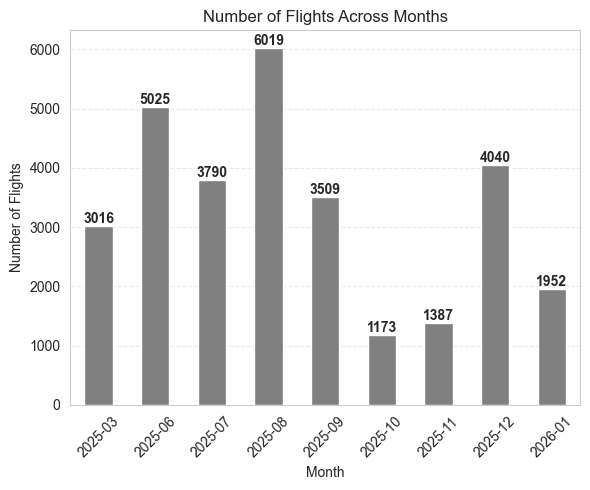

In [5]:
sns.set_style("whitegrid") 
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=monthly_df,
    x="Month",
    y="Flights",
    color="gray",
    width=0.5
)

plt.ylabel("Number of Flights")
plt.xlabel("Month")
plt.title("Number of Flights Across Months")

plt.xticks(rotation=45)

ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.grid(False)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [6]:
monthly_df = monthly_df.sort_values("Month")

x = np.arange(len(monthly_df))

train = monthly_df["N_train"].values
valid = monthly_df["N_valid"].values
test  = monthly_df["N_test"].values

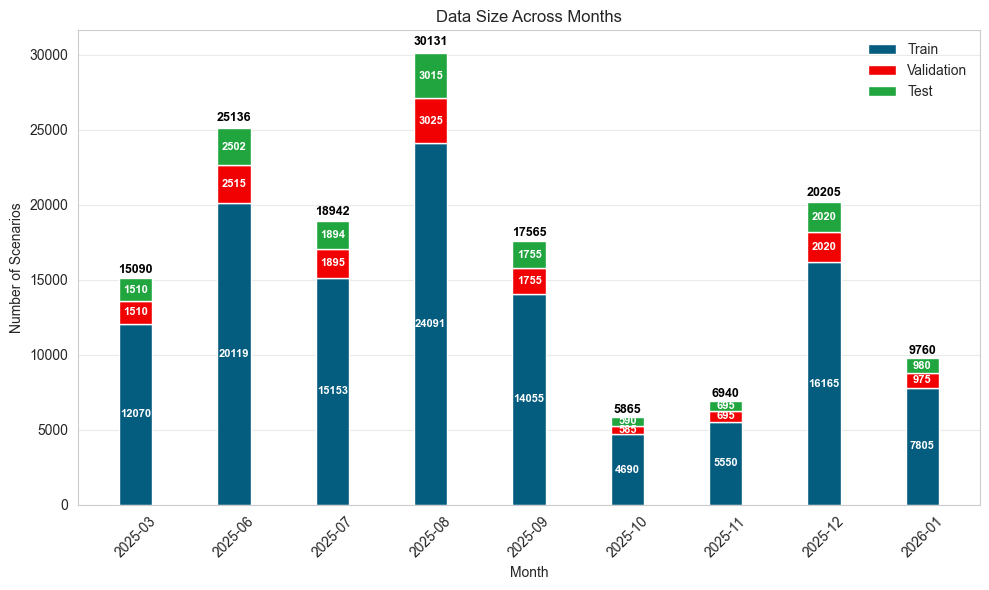

In [7]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
plt.grid(axis='x', visible=False)
plt.grid(axis='y', linestyle='-', alpha=0.4)
width=0.34
bar1 = plt.bar(x, train, label="Train", color="#045C7F", width=width)
bar2 = plt.bar(x, valid, bottom=train, label="Validation", color="#F10101", width=width)
bar3 = plt.bar(x, test,  bottom=train+valid, label="Test", color="#20A53F",width=width)

def add_labels(bars, values, bottoms):
    for i, (bar, val, bottom) in enumerate(zip(bars, values, bottoms)):
        if val > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bottom + val/2,
                f"{int(val)}",
                ha='center',
                va='center',
                fontsize=8,
                color="white",   
                fontweight='bold'
            )

add_labels(bar1, train, np.zeros_like(train))
add_labels(bar2, valid, train)
add_labels(bar3, test, train+valid)


totals = train + valid + test
for i, total in enumerate(totals):
    plt.text(
        x[i],
        total + total*0.01,
        f"{int(total)}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color="black"
    )

# 🔥 axis
plt.xticks(x, monthly_df["Month"], rotation=45)
plt.ylabel("Number of Scenarios")
plt.xlabel("Month")
plt.title("Data Size Across Months")



plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [49]:
def concordance_corr_coef(y_true, y_pred):
    x = np.array(y_true)
    y = np.array(y_pred)

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    var_x = np.var(x)
    var_y = np.var(y)

    cov_xy = np.mean((x - mean_x) * (y - mean_y))

    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y)**2)
    return ccc

In [53]:
def regression_metrics(y_true, y_pred, n_features=1, file_path="/Users/YGT/ist-airport-decision-support-system/artifacts/llm_delay_qwen/2025-03/test_predictions.csv"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    path_obj = Path(file_path)
    month_name = path_obj.parent.name

    mae = round(mean_absolute_error(y_true, y_pred), 4)
    mse = round(mean_squared_error(y_true, y_pred), 4)
    rmse = round(np.sqrt(mse), 4)
    r2 = round(r2_score(y_true, y_pred), 4)

    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


    epsilon = 1e-8
    smape = round(np.mean(
        np.abs(y_true - y_pred) / 
        (np.abs(y_true) + np.abs(y_pred) + epsilon)
    ) * 100, 4)

    r, p = spearmanr(y_true, y_pred)
    ccc = concordance_corr_coef(y_true, y_pred)

    return {
        "Month":[month_name],
        "MAE": [mae],
        "MSE": [mse],
        "RMSE": [rmse],
        "R2": [r2],
        "Adj_R2": [round(adj_r2,4)],
        "SMAPE": [smape],
        "Spearman ρ (p)": [f"{round(r,4)} ({round(p,4)})"],
        "CCC": [round(ccc,4)]

    }

In [54]:
march_performance = regression_metrics(df["y_true"], df["y_pred"])


In [55]:
march_performance

{'Month': ['2025-03'],
 'MAE': [2.0206],
 'MSE': [7.3706],
 'RMSE': [np.float64(2.7149)],
 'R2': [0.7934],
 'Adj_R2': [0.7933],
 'SMAPE': [np.float64(7.3084)],
 'Spearman ρ (p)': ['0.9101 (0.0)'],
 'CCC': [np.float64(0.8981)]}

In [56]:
metrics_df = pd.DataFrame(data=march_performance)

In [57]:
metrics_df

,Month,MAE,MSE,RMSE,R2,Adj_R2,SMAPE,Spearman ρ (p),CCC
0,2025-03,2.0206,7.3706,2.7149,0.7934,0.7933,7.3084,0.9101 (0.0),0.8981
